In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
u_nn = np.load('solution.npz', allow_pickle=True)
u_nn_exact = np.load('burgers_viscid_data.npz', allow_pickle=True)

u_rk4 = np.load('rk4.npz', allow_pickle=True)
u_exact_rk4 = np.load('u_exact_rk4.npz', allow_pickle=True)

In [3]:
(u_nn['Yhat_val'].shape, u_nn_exact['u'].shape), (u_rk4['u_rk4'].shape, u_exact_rk4['u_exact_rk4'].shape)

(((128, 128), (128, 128)), ((3, 201), (3, 201)))

In [4]:
t = u_nn_exact['t']

## Plots

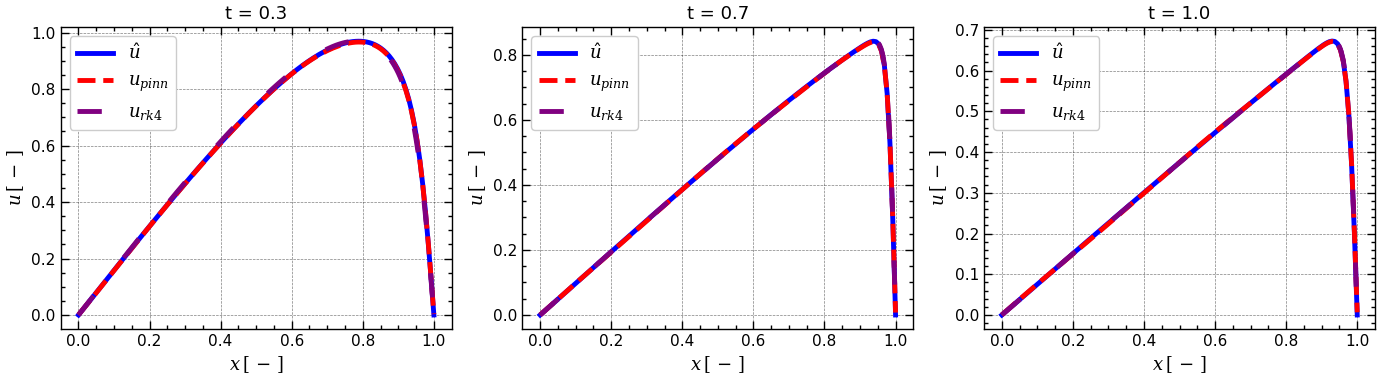

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for i, j in enumerate(np.searchsorted(t, [0.3, 0.7, 1])):
    axs[i].plot(u_nn_exact['x'], u_nn_exact['u'][:, j], color='blue', linestyle='solid', linewidth=3.5, label='$\hat{u}$')
    axs[i].plot(u_nn['x'], u_nn['Yhat_val'][:, j], color='red', linestyle='dashed', linewidth=3.5, label='$u_{pinn}$')
    axs[i].plot(u_rk4['x'], u_rk4['u_rk4'][i], color='purple', linestyle=(0, (5, 10)), linewidth=3.5, label='$u_{rk4}$')
    
    axs[i].xaxis.set_tick_params(labelsize=11)
    axs[i].yaxis.set_tick_params(labelsize=11)
    
    axs[i].set_xlabel('$x\,[\,-\,]$', fontsize=13)
    axs[i].set_ylabel('$u\,[\,-\,]$', fontsize=13)
    
    axs[i].set_title(f't = {round(t[j], 1)}', fontsize=13)
    axs[i].legend(fontsize=13)
plt.tight_layout()
plt.savefig('burgers_viscid.pdf')

# Eror analysis

In [6]:
def compute_errors(u, u_hat):
    N = u.shape[0]
    print(f'N = {N}')
    l2 = np.sqrt((1 / N) * np.sum(np.square(u - u_hat)))
    l_inf = np.max(u - u_hat)
    l_relative = l2 / np.sqrt(np.sum(np.square(u))) * 100
    print(f'L2 = {round(l2, 6)}')
    print(f'L_inf = {round(l_inf, 6)}')
    print(f'L_relative = {round(l_relative, 6)} %')

In [7]:
# PINN
compute_errors(u_nn_exact['u'][:, -1], u_nn['Yhat_val'][:, -1])

N = 128
L2 = 0.001199
L_inf = 0.001853
L_relative = 0.025945 %


In [8]:
# RK4
compute_errors(u_exact_rk4['u_exact_rk4'][-1], u_rk4['u_rk4'][-1])

N = 201
L2 = 0.000607
L_inf = 0.000539
L_relative = 0.01046 %
